# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
data = pd.read_csv("foodhub_order.csv")
df = data.copy()

In [ ]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
df.shape

(1898, 9)

#### Observations:


*   The dataset contains 1,898 rows and 9 columns.





### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
* All nine columns contain 1,898 records indicating values are populated in each row.
* Four object type columns exist: restaurant_name, cuisine_type, day_of_the_week, and rating.
* Food_preparation_time and delivery_time read as 'int64' but should be in 'float64' format to bring more precision to food prep time and delivery time.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
missing_values = df.isnull().sum()
print(missing_values)

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


#### Observations:
* Running a check across each data frame confirms there are no missing values across the nine column dataset.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
* Minimum time for food preparation, after order is placed: 20.00 minutes
* Average time for food preparation, after order is placed: 27.37 minutes
* Maximum time for food preparation, after ordeer is placed: 35.00 minutes


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
has_score_not_rated = (df['rating'] == "Not given").sum()
print(has_score_not_rated)

736


#### Observations:
* Based on earlier explorations, we know orders not rated contain a 'Not given' value.
* With this insight, I calculated the number of rows in the ratings column with the value 'Not given'.
* 736 orders are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

### "Order_Id" Observations
* Order_id functions as a unique identifier for all customer orders.
* Given this context, I focused my efforts to ensure maximum data quality.
* This dataset returned the correct number of unique orders, did not contain any duplicate values, and did not contain any lines with multiple values.

In [ ]:
# Write code here
summary = {
    "total_rows": len(df),
    "unique_orders": df['order_id'].nunique(),
    "duplicate_orders": df['order_id'].duplicated().sum(),
    "max_lines_per_order": df.groupby('order_id').size().max()
}
summary


{'total_rows': 1898,
 'unique_orders': 1898,
 'duplicate_orders': np.int64(0),
 'max_lines_per_order': 1}

### "Customer_ID" Observations
* Customer_id serves as a unique customer identifier for this dataset. While each order ID must be unique, a single customer may choose to place multiple orders.
* In this sample, 1,200 unique customers placed orders, meaning 698 orders were placed by repeat customers.
* Customer ID's "max_lines_per_order" value was 13, prompting further investigation. With a mean of 1.5 and a standard deviation of 1.1, the '13' value is an outlier likely caused by join errors or potential fraud. Further investigation is required here.

In [ ]:
# Write code here
summary = {
    "total_rows": len(df),
    "unique_orders": df['customer_id'].nunique(),
    "duplicate_orders": df['customer_id'].duplicated().sum(),
    "max_lines_per_order": df.groupby('customer_id').size().max()
}
print(summary)
df.groupby('customer_id').size().describe()


{'total_rows': 1898, 'unique_orders': 1200, 'duplicate_orders': np.int64(698), 'max_lines_per_order': 13}


,0
count,1200.000000
mean,1.581667
std,1.090560
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,13.000000


### "Restaurant_Name" Observations
* Initial discovery efforts identified 178 unique restaurants in the "restaurant_name" column.
* Since "restaurant_name" is a categorical variable, I created a countplot based on restaurant popularity.
* To create a readable countplot, I limited display to the top 15 most popular restaurants customers ordered from.

178
Index(['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi',
       'Blue Ribbon Fried Chicken', 'Parm', 'RedFarm Broadway',
       'RedFarm Hudson', 'TAO', 'Han Dynasty', 'Blue Ribbon Sushi Bar & Grill',
       'Nobu Next Door', 'Sushi of Gari 46', 'Rubirosa', 'Momoya',
       'Five Guys Burgers and Fries'],
      dtype='object', name='restaurant_name')


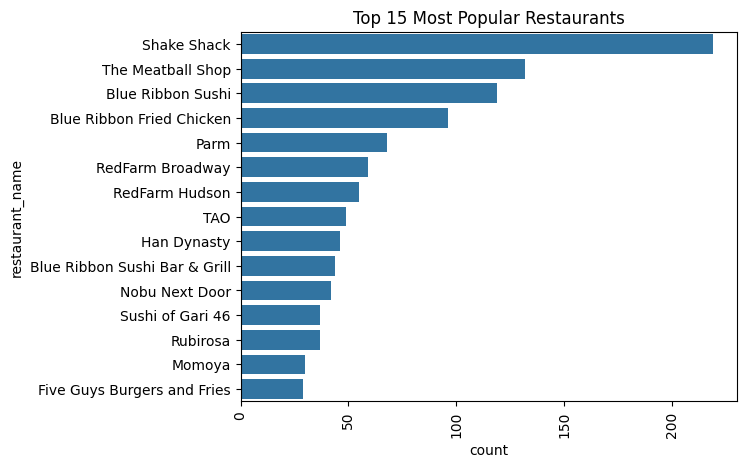

In [ ]:
# Write code here
unique_count = df['restaurant_name'].nunique()
print(unique_count)
top_n = 15
top_restaurants = df['restaurant_name'].value_counts().head(top_n).index
print(top_restaurants)
sns.countplot(order=top_restaurants, data=df, y="restaurant_name",)
plt.xticks(rotation=90)
plt.title(f'Top {top_n} Most Popular Restaurants')
plt.show()

### "Cuisine_Type" Observations
* Before I started plotting, I identified 14 unique values in the 'cuisine_type' dataset.
* With this in mind, I created a horizontal countplot to visually articulate the most popular cuisines.
* American, Japanese, Italian, and Chinese cuisines are the most popular, with each registering over 200 orders.
* American and Japanese are significantly more popular than all other cuisines (450+ orders each).

14


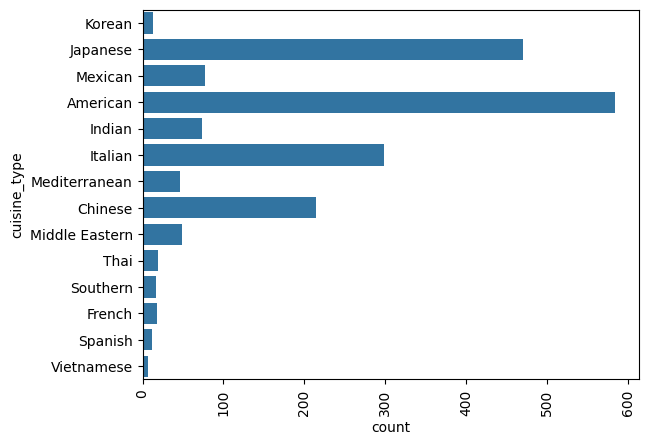

In [ ]:
# Write the code here
unique_count = df['cuisine_type'].nunique()
print(unique_count)
sns.countplot(data=df, y="cuisine_type")
plt.xticks(rotation=90)
plt.show()

### "Cost_of_the_Order" Obervations
* The distribution of "cost_of_the_ordeer" is slightly right skewed, with 50% of the orders priced under ~ $14.

* 25 percent of orders cost less than 11 dollars, 50 percent of orders cost less than 14 dollars, and 75 percent of orders cost less than $22.50.

* There are no visible outliers in this variable.

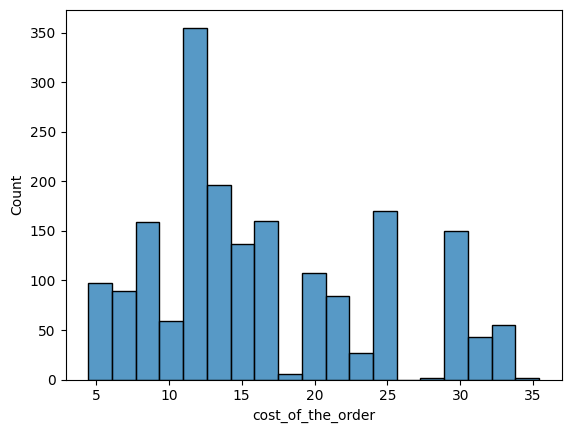

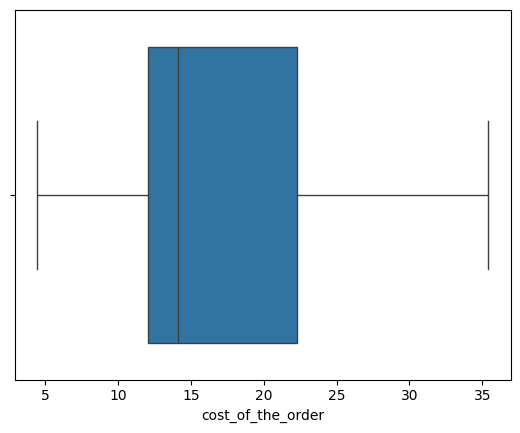

In [ ]:
# Write code here
sns.histplot(data=df, x="cost_of_the_order")
plt.show()
sns.boxplot(data=df, x="cost_of_the_order")
plt.show()

### "Day_of_the_Week" Observations
* Weekends are the more popular time to order from Foodhub by more than a 2:1 ratio.
* This data should be broken down into specific days to create more actionable insights.

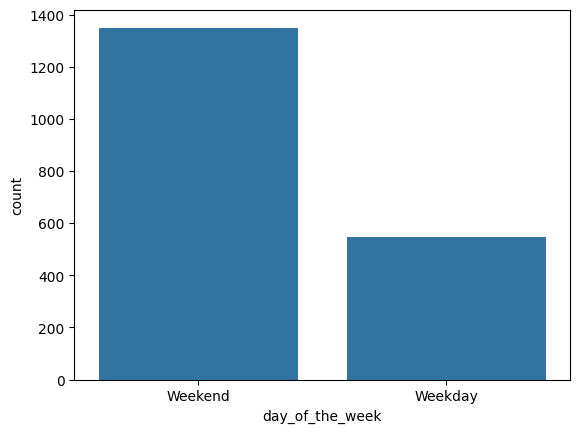

In [ ]:
# Write the code here
sns.countplot(data=df, x="day_of_the_week")
plt.show()

### "Rating" Observations
* Over 700 orders did not receive a rating; opportunity to enhance product to increase the number of order ratings.
* Of the orders with a rating, 5 star and 4 star ratings outweighed 3 star ratings.
* Users with a negative experience may be inclined to not rate the app since a 2 star or 1 star rating is not available. This may be hiding product experience issues within the application.

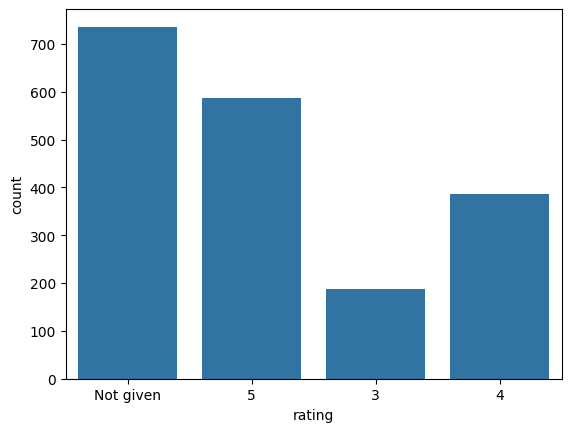

In [ ]:
# Write the code here
sns.countplot(data=df, x="rating")
plt.show()

### "Food_Preparation_Time" Observations:
* Food preparation time is stored as an integer, which can only take whole number values.
* Despite a relatively even value distribution, the histogram creates artificial spikes when binned.
* In this scenario, a histogram is the wrong primary visualization tool.
* When evaluating the boxplot, the breakdown becomes more clear: 25 percent of orders took less than 23 minutes, 50 percent took less than 27, and 75 percent took less than 31.

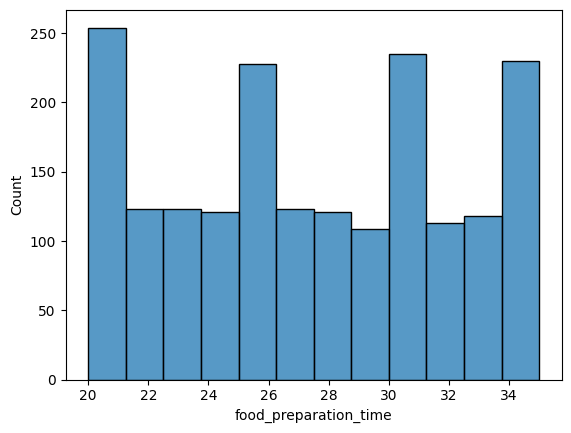

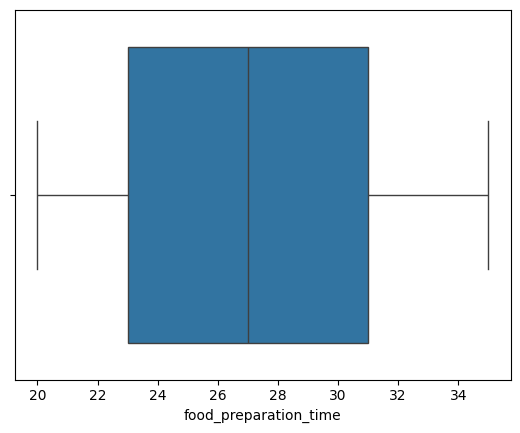

,count
food_preparation_time,
20,119
21,135
22,123
23,123
24,121
25,113
26,115
27,123
28,121


In [ ]:
# Write the code here
sns.histplot(data=df, x="food_preparation_time")
plt.show()
sns.boxplot(data=df, x="food_preparation_time")
plt.show()
df['food_preparation_time'].value_counts().sort_index()

### "Delivery_Time" Observations
* Delivery time values are also stored as integers, creating the same problem as above - historgrams create artifical spikes when binned.
* When evaluating the boxplot, the breakdown becomes more clear: 25 percent of orders took less than 20 minutes to deliver, 50 percent took less than 25 minutes to deliver, and 75 percent took less than 28.

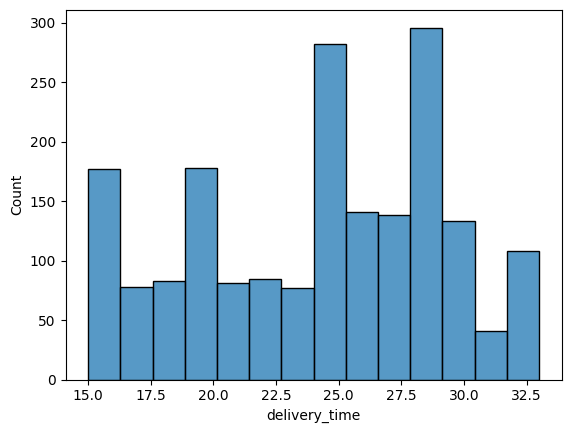

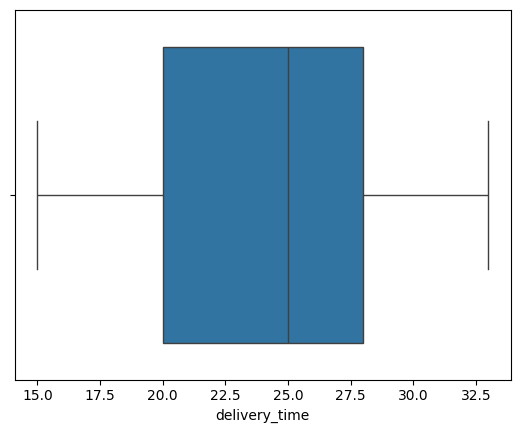

In [ ]:
# Wrire the code here
sns.histplot(data=df, x="delivery_time")
plt.show()
sns.boxplot(data=df, x="delivery_time")
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

Index(['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi',
       'Blue Ribbon Fried Chicken', 'Parm'],
      dtype='object', name='restaurant_name')


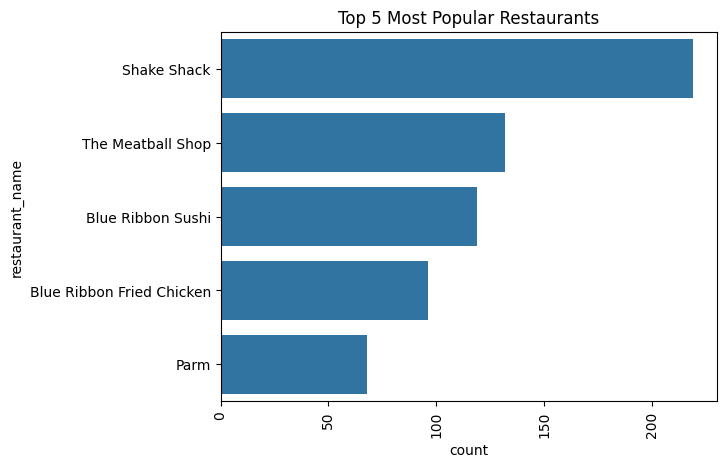

In [ ]:
# Write the code here
top_n = 5
top_restaurants = df['restaurant_name'].value_counts().head(top_n).index
print(top_restaurants)
sns.countplot(order=top_restaurants, data=df, y="restaurant_name",)
plt.xticks(rotation=90)
plt.title(f'Top {top_n} Most Popular Restaurants')
plt.show()

#### Observations:
* Following the same formula I used above, I calculated the total value counts for each restaurant appearing in the dataset before limiting my countplot to the top 5.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
weekend_cuisine_counts = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()
print(weekend_cuisine_counts)

cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Middle Eastern     32
Mediterranean      32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64


#### Observations:
* Weekend cuisine popularity followed the plots above, with American, Japanese, Italian, and Chinese remaining the four most popular.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
over_20 = df[df['cost_of_the_order'] > 20]
over_20_percent = (len(over_20) / len(df)) * 100
print(over_20_percent)

29.24130663856691


#### Observations:
* To calculate the percentage of orders above 20 dollars, I first calculated the total number of orders above 20.
* Next, I divided the number of order above 20 by the total number of records before multiplying by 100.
* 29.24% of orders cost more than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
* Using the df.describe method from above, we can identify the mean order delivery time as 24.16 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
top_customers = df['customer_id'].value_counts().head(3)
print(top_customers)


NameError: name 'df' is not defined

#### Observations:
* Since a customer ID is linked to every order, I counted the number of times the top 3 customer ID appeared across the dataset.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


### Relationships between Numerical Variables
* Weak positive and negative relationships exist across the numberical variables in this dataset.
* However, there is a slight positive correlation in cost of the order and food preparation time, possibly suggesting more expensive food takes longer to prepare.
* There is a slight negative correlation between cost of the order and delivery time, suggesting cheaper orders are delivered faster.

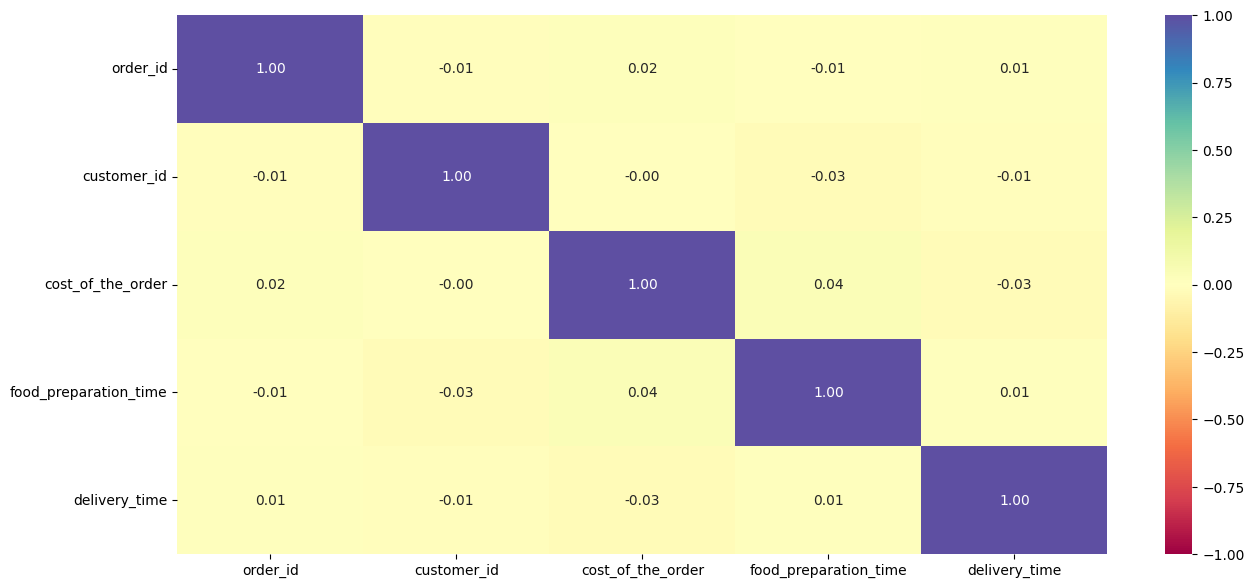

In [ ]:
# Write the code here
num_var = df.dtypes[df.dtypes != 'object'].index
corr = df[num_var].corr(numeric_only = True)

plt.figure(figsize=(15, 7))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

### Relationships between Categorical Variables
* Ratings are very similar on weekdays and weekends; day of week does not meaningfully impact customer ratings.
* Rating by cuisine type is influenced by sample size; however, Indian, Italian, and Vietenemese skew more strongly toward 5-star ratings.
* Cuisine preferences on weekdays vs weekends are largely stable; American and Japanese dominate both categories. Chinese, however, sees a noticeable uptick on weekends.

In [ ]:
# Write the code here
print(pd.crosstab(df['rating'], df['day_of_the_week'], normalize='columns'))

print(pd.crosstab(df['rating'], df['cuisine_type'], normalize='columns'))

print(pd.crosstab(df['cuisine_type'], df['day_of_the_week'], normalize='columns'))



day_of_the_week   Weekday   Weekend
rating                             
3                0.115174  0.092524
4                0.199269  0.205033
5                0.307130  0.310881
Not given        0.378428  0.391562
cuisine_type  American   Chinese    French    Indian   Italian  Japanese  \
rating                                                                     
3             0.109589  0.111628  0.111111  0.068493  0.093960  0.085106   
4             0.222603  0.186047  0.166667  0.178082  0.181208  0.193617   
5             0.297945  0.320930  0.277778  0.438356  0.302013  0.302128   
Not given     0.369863  0.381395  0.444444  0.315068  0.422819  0.419149   

cuisine_type    Korean  Mediterranean   Mexican  Middle Eastern  Southern  \
rating                                                                      
3             0.153846       0.195652  0.077922        0.102041  0.058824   
4             0.307692       0.152174  0.207792        0.326531  0.411765   
5             0.230

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
# Replace 'Not given' with NaN, convert to numeric, then calculate mean
df['rating'] = df['rating'].replace('Not given', np.nan).astype(float)
rating_count = df.groupby('restaurant_name')['rating'].count()
average_rating = df.groupby('restaurant_name')['rating'].mean()

# Filter for restaurants fulfilling the criteria
restaurants_for_promo = average_rating[(rating_count > 50) & (average_rating > 4)]
print(restaurants_for_promo)

restaurant_name
Blue Ribbon Fried Chicken    4.328125
Blue Ribbon Sushi            4.219178
Shake Shack                  4.278195
The Meatball Shop            4.511905
Name: rating, dtype: float64


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
net_revenue = round(np.where(
    df['cost_of_the_order'] > 20,
    0.25 * df['cost_of_the_order'],
    np.where(df['cost_of_the_order'] > 5, 0.15 * df['cost_of_the_order'], 0)
).sum(),1)
print("Net revenue generated across all orders:",net_revenue)

Net revenue generated across all orders: 6166.3


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
pct_over_60 = round(((df['food_preparation_time'] + df['delivery_time']) > 60).mean() * 100,1)
print("Percentage of orders taking more than 60min to get delivered:",pct_over_60)

Percentage of orders taking more than 60min to get delivered: 10.5


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Three Core Conclusions:
*  American and Japanese cuisines are the most popular cuisines on the platform during the week or weekends.
*  Indian, Italian, and Vietenemase skew towards five star reviews while remaining more popular during the week, which contradicts the broader platform's popularity on weekends.
*  Weekday delivery time is six minutes slower than weekend delivery time despite less traffic on the platform; potential causes include more traffic during the week (environmental), less available drivers (supply/demand imbalance), or limited earnings potential during the week (low ROI for drivers).

### Recommendations:

*  Further explore the correlation between delivery time and order volume; if positive correlation found, improve weekday delivery time to generate more weekday orders on the platform.
*  Given the outsized 5-star ratings for Indian food, enhance marketing options to increase orders and explore rating stickiness as orders increase.
*  Further analyze why 10% of orders take longer than 60 minutes to deliver. While food preparation time is outside FoodHub's control, ways to optimize delivery time may provide an outsized return on customer experience.

---